# Kinetic Evolution in Phase Space

Gradient descent is a first-order method: the iterate moves in the direction of the negative gradient. A natural generalisation is to consider the particle as having **momentum** — inertia that carries it past local minima and accelerates convergence. This leads to the **heavy-ball ODE**, which interprets gradient descent as a damped mechanical oscillator evolving in phase space.

## Double-well potential

We study dynamics on the **double-well potential**

$$
V(x) = \frac{1}{4}(x^2 - 1)^2,
$$

which has two minima at $x = \pm 1$, a local maximum at $x = 0$, and gradient

$$
\nabla V(x) = x(x^2 - 1).
$$

The potential barrier height is $V(0) - V(\pm 1) = \frac{1}{4}$, making it a challenging landscape for optimisation.

## Heavy-ball ODE

The **heavy-ball** (Polyak momentum) continuous-time system is the second-order ODE

$$
\ddot{x} + \gamma \dot{x} + \nabla V(x) = 0,
$$

which in phase-space form $(x, v) = (x, \dot{x})$ reads:

$$
\dot{x} = v, \qquad \dot{v} = -\nabla V(x) - \gamma v.
$$

Here $\gamma \geq 0$ is the **damping coefficient**:
- $\gamma = 0$: conservative dynamics, energy $E = \frac{1}{2}v^2 + V(x)$ is preserved and orbits are closed;
- $\gamma > 0$: energy dissipates monotonically; trajectories spiral into fixed points;
- critical damping: fastest convergence without oscillation.

The fixed points of the system satisfy $v = 0$ and $\nabla V(x) = 0$, i.e. $x \in \{-1, 0, 1\}$. Points $x = \pm 1$ are stable (potential minima); $x = 0$ is unstable (saddle in phase space).

This notebook:
- draws the phase portrait for several damping values;
- shows energy level sets and separatrices;
- explores the transition from oscillatory to overdamped regimes.

## Environment

In [1]:
import numpy as np
import matplotlib
if 'get_ipython' not in globals():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider

plt.rcParams['figure.dpi'] = 110

## Potential and gradient

We first visualise $V(x) = \frac{1}{4}(x^2-1)^2$ and its gradient $\nabla V(x) = x(x^2-1)$. The minima at $x=\pm 1$ and the saddle at $x=0$ are annotated.

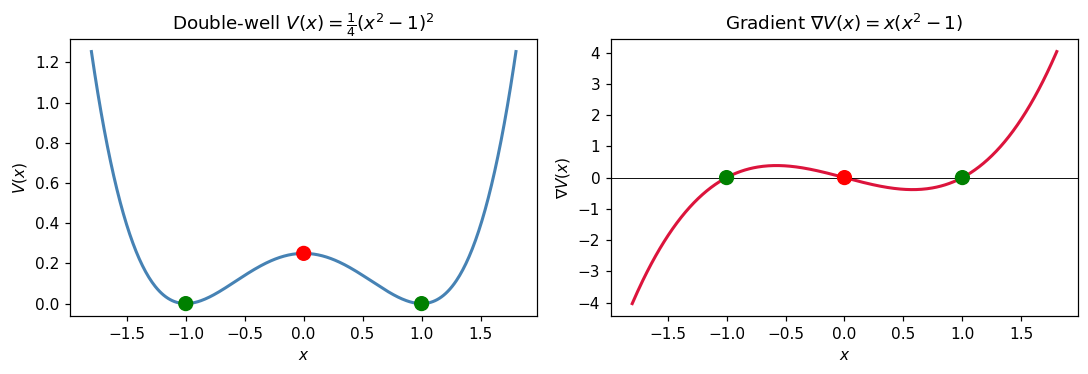

Saved potential.png


In [2]:
def V(x):
    return 0.25 * (x**2 - 1)**2

def dV(x):
    return x * (x**2 - 1)

xg = np.linspace(-1.8, 1.8, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(xg, V(xg), 'steelblue', lw=2)
axes[0].scatter([-1, 0, 1], [V(-1), V(0), V(1)],
                c=['g', 'r', 'g'], s=80, zorder=5)
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$V(x)$')
axes[0].set_title('Double-well $V(x) = \\frac{1}{4}(x^2-1)^2$')

axes[1].plot(xg, dV(xg), 'crimson', lw=2)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].scatter([-1, 0, 1], [0, 0, 0], c=['g', 'r', 'g'], s=80, zorder=5)
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$\\nabla V(x)$')
axes[1].set_title('Gradient $\\nabla V(x) = x(x^2-1)$')

plt.tight_layout()
plt.show()
plt.savefig('potential.png', bbox_inches='tight')
plt.close()
print('Saved potential.png')

## ODE integrator

We use `scipy.integrate.solve_ivp` with the RK45 method to integrate the heavy-ball ODE. The right-hand side is

$$
\frac{d}{dt}\begin{pmatrix}x\\v\end{pmatrix} = \begin{pmatrix}v \\ -\nabla V(x) - \gamma v\end{pmatrix}.
$$

In [3]:
def heavy_ball_rhs(t, state, gamma):
    x, v = state
    return [v, -dV(x) - gamma * v]

def integrate(x0, v0, gamma, t_end=20.0, n_pts=2000):
    t_span = (0, t_end)
    t_eval = np.linspace(0, t_end, n_pts)
    sol = solve_ivp(heavy_ball_rhs, t_span, [x0, v0],
                    args=(gamma,), t_eval=t_eval, method='RK45',
                    rtol=1e-8, atol=1e-10)
    return sol.y[0], sol.y[1], sol.t

## Phase portraits for varying damping $\gamma$

The **phase portrait** is a plot of trajectories in the $(x, v)$ plane. For $\gamma = 0$ (conservative), trajectories are closed curves corresponding to constant energy $E = \frac{1}{2}v^2 + V(x)$. As damping increases, trajectories spiral inward toward the fixed points $(-1, 0)$ or $(+1, 0)$.

The **separatrix** is the special trajectory that asymptotically approaches the unstable fixed point $(0, 0)$; it divides the basins of attraction of the two wells.

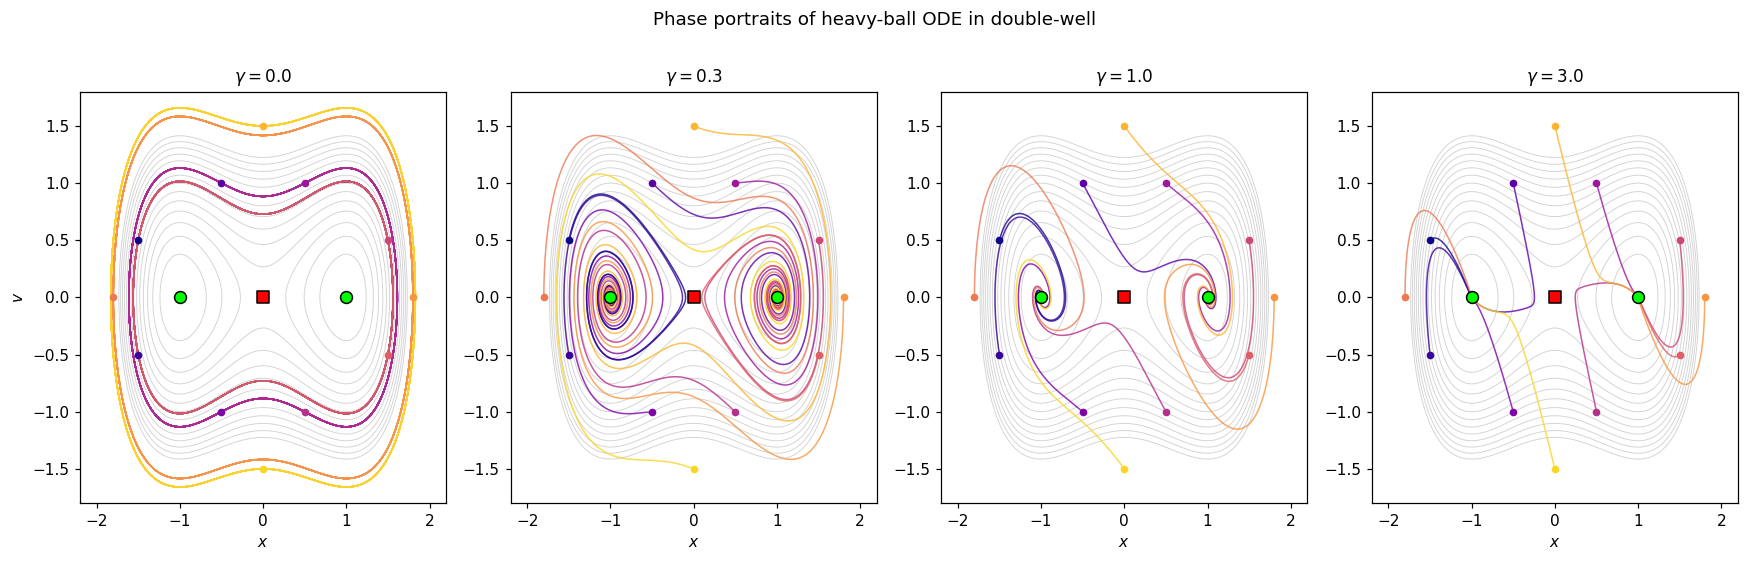

Saved phase_portraits.png


In [4]:
# Initial conditions: grid covering both wells
ic_list = [
    (-1.5, 0.5), (-1.5, -0.5), (-0.5, 1.0), (-0.5, -1.0),
    (0.5,  1.0), (0.5,  -1.0), (1.5,  0.5), (1.5, -0.5),
    (-1.8, 0.0), (1.8, 0.0), (0.0, 1.5), (0.0, -1.5),
]

gamma_vals = [0.0, 0.3, 1.0, 3.0]
x_range = np.linspace(-2.2, 2.2, 300)
v_range = np.linspace(-1.8, 1.8, 300)
XX, VV = np.meshgrid(x_range, v_range)
# Energy landscape
EE = 0.5 * VV**2 + V(XX)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
cmap_traj = plt.cm.plasma

for ax, gamma in zip(axes, gamma_vals):
    # Energy contours
    ax.contour(XX, VV, EE, levels=np.linspace(0, 1.0, 15),
               colors='lightgray', linewidths=0.6, zorder=1)

    for k, (x0, v0) in enumerate(ic_list):
        xt, vt, tt = integrate(x0, v0, gamma, t_end=30)
        color = cmap_traj(k / len(ic_list))
        ax.plot(xt, vt, lw=1.0, color=color, alpha=0.8, zorder=2)
        ax.plot(xt[0], vt[0], 'o', ms=4, color=color, zorder=3)

    # Fixed points
    ax.scatter([-1, 1], [0, 0], c='lime', s=60, zorder=5, edgecolors='k')
    ax.scatter([0], [0], c='red', s=60, zorder=5, edgecolors='k', marker='s')

    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-1.8, 1.8)
    ax.set_xlabel('$x$'); ax.set_ylabel('$v$' if ax is axes[0] else '')
    ax.set_title(f'$\\gamma = {gamma}$', fontsize=11)
    ax.set_aspect('auto')

fig.suptitle('Phase portraits of heavy-ball ODE in double-well', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
plt.savefig('phase_portraits.png', bbox_inches='tight')
plt.close()
print('Saved phase_portraits.png')

## Time-domain traces: $x(t)$ and $v(t)$

The phase portrait collapses time. To see oscillation frequency, decay rate, and well-switching, we plot $x(t)$ and $v(t)$ against time for four damping values from a common initial condition $(x_0, v_0) = (-0.5, 1.0)$.

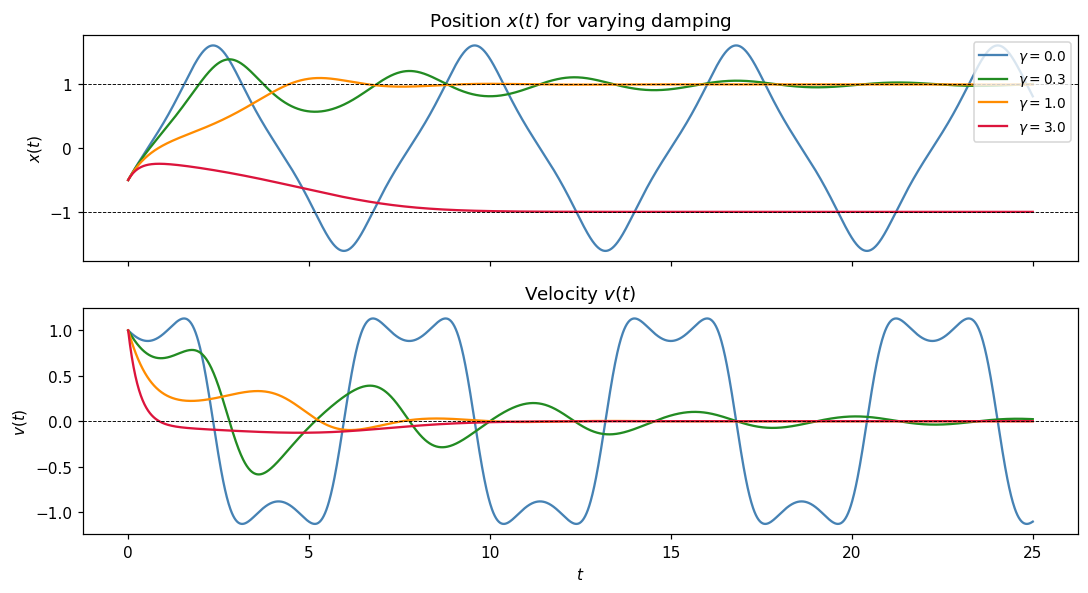

Saved time_traces.png


In [5]:
x0, v0 = -0.5, 1.0
colors_g = ['steelblue', 'forestgreen', 'darkorange', 'crimson']

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for gamma, c in zip(gamma_vals, colors_g):
    xt, vt, tt = integrate(x0, v0, gamma, t_end=25)
    axes[0].plot(tt, xt, lw=1.5, color=c, label=f'$\\gamma={gamma}$')
    axes[1].plot(tt, vt, lw=1.5, color=c)

axes[0].axhline(-1, color='k', lw=0.6, ls='--')
axes[0].axhline(1,  color='k', lw=0.6, ls='--')
axes[0].set_ylabel('$x(t)$')
axes[0].set_title('Position $x(t)$ for varying damping')
axes[0].legend(loc='upper right', fontsize=9)

axes[1].axhline(0, color='k', lw=0.6, ls='--')
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('$v(t)$')
axes[1].set_title('Velocity $v(t)$')

plt.tight_layout()
plt.show()
plt.savefig('time_traces.png', bbox_inches='tight')
plt.close()
print('Saved time_traces.png')

## Energy dissipation

The total mechanical energy $E(t) = \frac{1}{2}v(t)^2 + V(x(t))$ satisfies

$$
\dot{E} = v\dot{v} + \nabla V(x)\dot{x} = v(-\nabla V(x) - \gamma v) + \nabla V(x) v = -\gamma v^2 \leq 0.
$$

For $\gamma > 0$ the energy is strictly decreasing along non-stationary trajectories. For $\gamma = 0$ it is exactly conserved (numerical drift reflects integration error).

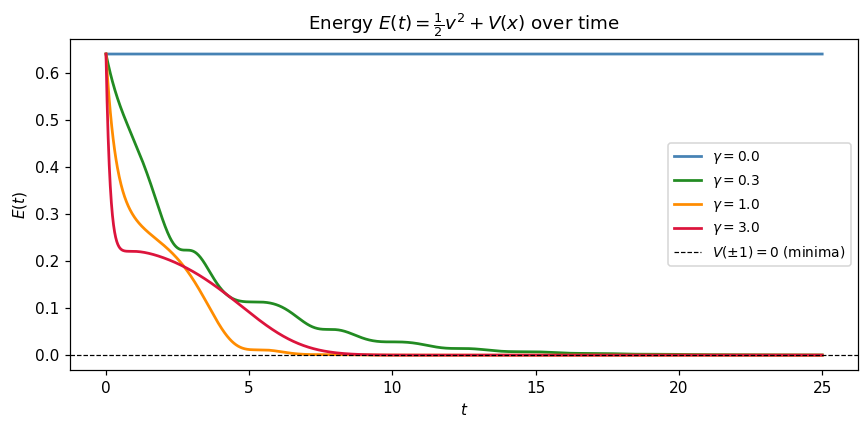

Saved energy.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for gamma, c in zip(gamma_vals, colors_g):
    xt, vt, tt = integrate(x0, v0, gamma, t_end=25)
    Et = 0.5 * vt**2 + V(xt)
    ax.plot(tt, Et, lw=1.8, color=c, label=f'$\\gamma={gamma}$')

ax.axhline(V(-1), color='k', lw=0.8, ls='--', label='$V(\\pm 1) = 0$ (minima)')
ax.set_xlabel('$t$'); ax.set_ylabel('$E(t)$')
ax.set_title('Energy $E(t) = \\frac{1}{2}v^2 + V(x)$ over time')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
plt.savefig('energy.png', bbox_inches='tight')
plt.close()
print('Saved energy.png')

## Vector field and nullclines

The **vector field** $(\dot{x}, \dot{v}) = (v,\, -\nabla V(x) - \gamma v)$ can be plotted as arrows over the phase plane. The **nullclines** where $\dot{x}=0$ (horizontal axis $v=0$) and where $\dot{v}=0$ (curve $v = -\nabla V(x)/\gamma$) intersect at fixed points.

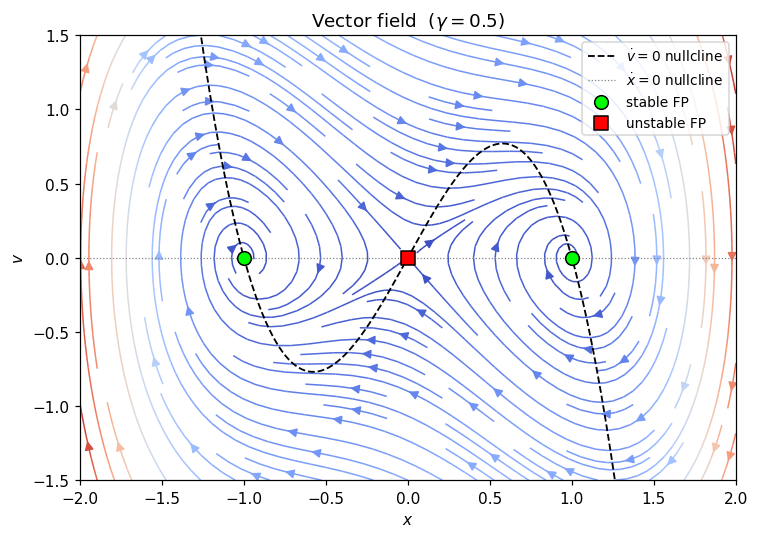

Saved vector_field.png


In [7]:
gamma_vf = 0.5
xq = np.linspace(-2.0, 2.0, 20)
vq = np.linspace(-1.5, 1.5, 20)
Xq, Vq = np.meshgrid(xq, vq)
DX = Vq
DV = -dV(Xq) - gamma_vf * Vq
speed = np.sqrt(DX**2 + DV**2) + 1e-12

fig, ax = plt.subplots(figsize=(7, 5))
ax.streamplot(xq, vq, DX, DV, color=speed, cmap='coolwarm',
              linewidth=1.0, density=1.3, arrowsize=1.2)

# Nullcline dot{v} = 0
xnc = np.linspace(-2.0, 2.0, 400)
vnc = -dV(xnc) / gamma_vf
ax.plot(xnc, vnc, 'k--', lw=1.2, label='$\\dot{v}=0$ nullcline')
ax.axhline(0, color='gray', lw=0.8, ls=':', label='$\\dot{x}=0$ nullcline')

ax.scatter([-1, 1], [0, 0], c='lime', s=80, zorder=5, edgecolors='k', label='stable FP')
ax.scatter([0], [0], c='red', s=80, zorder=5, marker='s', edgecolors='k', label='unstable FP')

ax.set_xlim(-2.0, 2.0); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('$x$'); ax.set_ylabel('$v$')
ax.set_title(f'Vector field  ($\\gamma = {gamma_vf}$)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
plt.savefig('vector_field.png', bbox_inches='tight')
plt.close()
print('Saved vector_field.png')

## Interactive phase portrait

The slider below lets you vary $\gamma$ continuously and watch trajectories evolve from the same set of initial conditions.

## Static snapshot

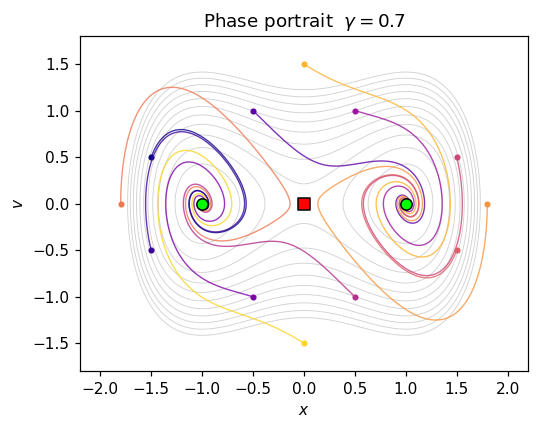

Saved snippet.png


In [8]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    gamma_snap = 0.7
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.contour(XX, VV, EE, levels=np.linspace(0, 1.0, 12),
               colors='lightgray', linewidths=0.6)
    for k, (x0i, v0i) in enumerate(ic_list):
        xt, vt, _ = integrate(x0i, v0i, gamma_snap, t_end=30)
        c = cmap_traj(k / len(ic_list))
        ax.plot(xt, vt, lw=0.9, color=c, alpha=0.8)
        ax.plot(xt[0], vt[0], 'o', ms=3, color=c)
    ax.scatter([-1, 1], [0, 0], c='lime', s=55, zorder=5, edgecolors='k')
    ax.scatter([0], [0], c='red', s=55, marker='s', zorder=5, edgecolors='k')
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-1.8, 1.8)
    ax.set_xlabel('$x$'); ax.set_ylabel('$v$')
    ax.set_title(f'Phase portrait  $\\gamma={gamma_snap}$')
    plt.tight_layout()
    plt.show()
    plt.savefig('snippet.png', bbox_inches='tight')
    plt.close()
    print('Saved snippet.png')

## Takeaways

- The heavy-ball ODE gives momentum-based gradient descent a dynamical systems interpretation: trajectories in phase space either orbit (underdamped) or spiral (damped) toward equilibria.
- The **double-well** potential has two stable fixed points separated by an unstable saddle; initial conditions and the energy determine which well the trajectory converges to.
- Energy is a Lyapunov function for $\gamma > 0$: it decreases strictly, guaranteeing convergence to a critical point.
- Critical damping $\gamma^* \approx 2\sqrt{V''(x^*)}$ achieves the fastest non-oscillatory convergence near a minimum.

## Bibliography

- Polyak, B. T. (1964). Some methods of speeding up the convergence of iteration methods. *USSR Computational Mathematics and Mathematical Physics*, 4(5), 1–17.
- Su, W., Boyd, S., and Candes, E. J. (2016). A differential equation for modeling Nesterov's accelerated gradient method. *JMLR*, 17(1), 5312–5354.
- Gelfand, I. M. and Fomin, S. V. (1963). *Calculus of Variations*. Prentice-Hall.
- Jordan, M. I. (2018). On gradient descent, momentum, and the heavy ball method. Lecture notes.